# Titanic - Machine Learning from Disaster

| Variable  | Definition                                   | Key                                      |
|-----------|----------------------------------------------|------------------------------------------|
| survival  | Survival                                     | 0 = No, 1 = Yes                          |
| pclass    | Ticket class                                 | 1 = 1st, 2 = 2nd, 3 = 3rd                |
| sex       | Sex                                          |                                          |
| age       | Age in years                                 |                                          |
| sibsp     | # of siblings / spouses aboard the Titanic   |                                          |
| parch     | # of parents / children aboard the Titanic   |                                          |
| ticket    | Ticket number                                |                                          |
| fare      | Passenger fare                               |                                          |
| cabin     | Cabin number                                 |                                          |
| embarked  | Port of Embarkation                          | C = Cherbourg, Q = Queenstown, S = Southampton |

---
## Import Libraries

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


---
## Read Files

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

---
## Explore the data

In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Based on this information this  gives us an idea of what might be interesting and what seems likely to be unnecessary. 

Things that might be unnecessary: 
- PassengerID,
- Cabin (too many null values, drop it)

This that might be interesting to keep: 
- Survived 
- Pclass (people with higher Title have higher chance of survival?)
- Age?

In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


Interesting notes: 
- min age => 0 : baby 
- max age => 80 
- Pclass => most common class was the second class 

A summary of all the non-numeric (text/categorical) colmuns in the dataframe:

In [6]:
# A summary of the categorical (text) columns
df_train.describe(include='O').T

C:\Users\fifif\AppData\Local\Temp\ipykernel_31528\3862125620.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_train.describe(include='O').T


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


Interesting note: 
- We see that ticket has 681 unique ticket from the 891 tickets in total which means that there are doubles
- we also see that Cabin also has a difference in the unique values, but this makes sense because multiple passengers can be assigned to the same cabin. 

In [7]:
count_cabin = df_train['Cabin'].isnull().sum()
print(count_cabin, " null values")

687  null values


Lookin at the missing values: 

In [8]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are missing values in:
-  age
- cabin => has the highest amount of missing values (687)
- embarked

This might be interesting if we decide to remove certain columns or fill those in. 

In [9]:
print(len(df_train))

891


---
##  Classes Likely to survive

Guess: 
- Ticket class : this will impact your likelyhood of survival. If you have a higher classs you might be closer to the exit
- Sex: This will def have an impact as Women and children and elderly are known to have a priority when it comes to disasters
- Age: Same things age does impact survivalhood children and elderly will be prioritised 

#### Survival based on Gender

In [10]:
#Look if women actualy had a higher survival rate than men
df_train.groupby(['Sex'], as_index=False)['Survived'].mean()


,Sex,Survived
0,female,0.742038
1,male,0.188908


Females had a higher percentage of survival with a 74% whereas male its as low as 19%.

#### Survival based on Pclass

In [11]:
#Look if class actually had an impact on survival
df_train.groupby(['Pclass'], as_index=False)['Survived'].mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


Also confirms our guess: 
- 62% of passengers who survived were sitted in the first class. 
- 47% of passengers who survived were from the second class. 
- only 24% of passengers who survived came from the third class. 

This confirms that the higher your Pclass, the higher your chance is of survival. 

#### Survival based on the amount of siblings/spouses onboard

In [12]:
df_train.groupby(['SibSp'], as_index=False)['Survived'].mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


#### Survival based on amount of children onboard

In [13]:
df_train.groupby(['Parch'], as_index=False)['Survived'].mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


Based on the information from the amount of spouse, siblings and children we can note that smaller/midsize families have a higher change of surviving the disaster. 

##### Combine SibSp and Parch for better insight

It's better to look broad in a family sense then seperately

In [14]:
df_train['Family-Size'] = df_train['SibSp'] + df_train['Parch'] + 1
df_test['Family-Size'] = df_test['SibSp'] + df_test['Parch'] + 1

In [15]:
df_train.groupby('Family-Size')['Survived'].mean()*100

Family-Size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

Note:
- a family between 2 and 4 have the highest chance of survival. 
- survival alone is lower than the average mean 

In [16]:
family_map = {1: "Alone", 2: "Small", 3: "Small", 4: "Small", 5: "Medium", 6: "Medium", 7: "Large", 8: "Large", 11: "Large"}

In [17]:
df_train['Family_Size_Grouped'] = df_train['Family-Size'].map(family_map)
df_test['Family_Size_Grouped'] = df_test['Family-Size'].map(family_map)

In [18]:
df_train.groupby(['Family_Size_Grouped'], as_index=False)['Survived'].mean()

,Family_Size_Grouped,Survived
0,Alone,0.303538
1,Large,0.160000
2,Medium,0.162162
3,Small,0.578767


#### Survival based on embarkment

In [19]:
df_train.groupby(['Embarked'], as_index=False)['Survived'].mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


Based on embarkement port we can see: 
- C = Cherbourg has the highest survival chance 
- S = Southhampton has the lowest survival chance

but why? 
How does the port of embarkement influence chance of survival? 
Is this merely by change or is this influenced class from where they departed? 


Check if this is true? 
(ChatGPT)

In [20]:
pd.crosstab(df_train['Embarked'], df_train['Pclass'])

Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


In [21]:
pd.crosstab(
    df_train['Embarked'],
    df_train['Pclass'],
    normalize='index'
) * 100

Pclass,1,2,3
Embarked,,,
C,50.595238,10.119048,39.285714
Q,2.597403,3.896104,93.506494
S,19.720497,25.465839,54.813665


In [22]:
df_train.groupby(['Embarked', 'Pclass'])['Survived'].mean() * 100

Embarked  Pclass
C         1         69.411765
          2         52.941176
          3         37.878788
Q         1         50.000000
          2         66.666667
          3         37.500000
S         1         58.267717
          2         46.341463
          3         18.980170
Name: Survived, dtype: float64

This confirms our guess: 
- There must be a relationship between place of embarkement and Pclass
- most first class passengers embarked from Cherbourg

Since we already know that women had a higher chance of survival also check if that's the case in Cherbourg

In [39]:
pd.crosstab(
    [df_train['Embarked'], df_train['Pclass']],
    df_train['Sex'],
    normalize='index'
) * 100

Sex                 female       male
Embarked Pclass                      
C        1       50.588235  49.411765
         2       41.176471  58.823529
         3       34.848485  65.151515
Q        1       50.000000  50.000000
         2       66.666667  33.333333
         3       45.833333  54.166667
S        1       37.795276  62.204724
         2       40.853659  59.146341
         3       24.929178  75.070822

Here we can see that there were women in Cherbough compared Southhampton. 
We can take away the Southhampton had mostly male passengers and the lowest survival chances. 
After some searching online it showed that southhampton was the port of departure where the majority of the crew and also lower class boarded.
To add those who resided in the third class had lower chance of surviving because the lower-class cabines were located on the lower and forward decks which were also the furthest away from the boat where the lifeboats were.  

We can take away that the port itself does not directly determine the survival but the port mainly reflects the passengers class and gender. 

Source: https://pubmed.ncbi.nlm.nih.gov/3520835/

#### Survival based on age

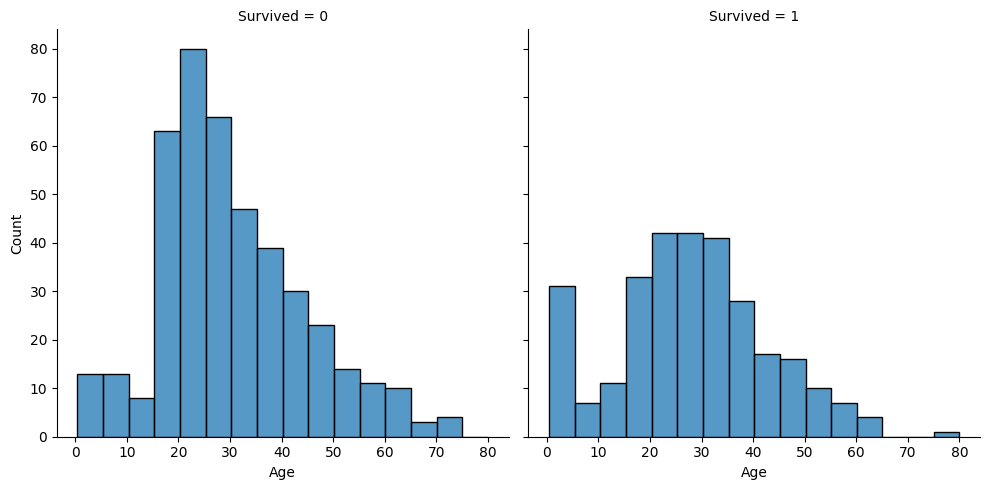

In [42]:
sns.displot(data=df_train, x='Age', col='Survived', bins=16)

In [43]:
#split age into 8 equal bins 
df_train['Age_Cut'] = pd.qcut(df_train['Age'], 8)
df_test['Age_Cut'] = pd.qcut(df_test['Age'], 8)

In [44]:
df_train.groupby(['Age_Cut'], as_index=False)['Survived'].mean()

,Age_Cut,Survived
0,"(0.419, 16.0]",0.550000
1,"(16.0, 20.125]",0.341772
2,"(20.125, 24.0]",0.367347
3,"(24.0, 28.0]",0.352941
4,"(28.0, 32.312]",0.416667
5,"(32.312, 38.0]",0.450549
6,"(38.0, 47.0]",0.329545
7,"(47.0, 80.0]",0.415730


Highest age of survival were mostly young adults and middle aged passengers.

In [45]:
#making bins to make it easier to read

df_train.loc[df_train['Age']<=16, 'Age'] = 0
df_train.loc[(df_train['Age']> 16) & (df_train['Age']<=20.125), 'Age'] = 1
df_train.loc[(df_train['Age']> 20.125) & (df_train['Age']<=24), 'Age'] = 2
df_train.loc[(df_train['Age']> 24) & (df_train['Age']<=28), 'Age'] = 3
df_train.loc[(df_train['Age']> 28) & (df_train['Age']<=32.312), 'Age'] = 4
df_train.loc[(df_train['Age']> 32.312) & (df_train['Age']<=38), 'Age'] = 5
df_train.loc[(df_train['Age']> 38) & (df_train['Age']<=47), 'Age'] = 6
df_train.loc[(df_train['Age']> 47) & (df_train['Age']<=80), 'Age'] = 7
df_train.loc[df_train['Age'] > 80, 'Age']

df_test.loc[df_test['Age']<=16, 'Age'] = 0
df_test.loc[(df_test['Age']> 16) & (df_test['Age']<=20.125), 'Age'] = 1
df_test.loc[(df_test['Age']> 20.125) & (df_test['Age']<=24), 'Age'] = 2
df_test.loc[(df_test['Age']> 24) & (df_test['Age']<=28), 'Age'] = 3
df_test.loc[(df_test['Age']> 28) & (df_test['Age']<=32.312), 'Age'] = 4
df_test.loc[(df_test['Age']> 32.312) & (df_test['Age']<=38), 'Age'] = 5
df_test.loc[(df_test['Age']> 38) & (df_test['Age']<=47), 'Age'] = 6
df_test.loc[(df_test['Age']> 47) & (df_test['Age']<=80), 'Age'] = 7
df_test.loc[df_test['Age'] > 80, 'Age']

Series([], Name: Age, dtype: float64)

Check again: 

In [46]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family-Size,Family_Size_Grouped,Age_Cut
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,7.2500,NaN,S,2,Small,"(20.125, 24.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,71.2833,C85,C,2,Small,"(32.312, 38.0]"
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Alone,"(24.0, 28.0]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,53.1000,C123,S,2,Small,"(32.312, 38.0]"
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,8.0500,NaN,S,1,Alone,"(32.312, 38.0]"


Now we can see that our changes have been applied and it's easier to look at the age category

---

Look at the people who survived

In [25]:
df_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [26]:
survival_rate = df_train['Survived'].value_counts(normalize=True)
print((survival_rate * 100), "%")


Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64 %


Look at the balance between those who have survived and those who didn't
We see that 61% did not survive whereas 38% did survive the disaster

Within those people look at the title they have as this also impact. We already know that class has an impact but if we search further we can check if the title of a person also influenced or not?

Look if the groupsize actually matter in surving? 

To do this it's best to combine them to like at family size in general. 
By combining the total family size, which is what actually matters for survival. And we also add  one to count for the passenger itself

Map to family to its size. 

In [27]:
df_train.groupby('Ticket')['Survived'].mean()*100

Ticket
110152         100.000000
110413          66.666667
110465           0.000000
110564         100.000000
110813         100.000000
                  ...    
W./C. 6608       0.000000
W./C. 6609       0.000000
W.E.P. 5734      0.000000
W/C 14208        0.000000
WE/P 5735       50.000000
Name: Survived, Length: 681, dtype: float64

Data Cleaning: 
Based on the findings the data needs some cleaning some things will be dropped other will be filled
- Cabin --> drop because it has a lot of missing values
- Age --> fill with the median 
- Embarked --> fill with mode only 2 are missing
- PassengerId, Name, Ticket --> drop (not predictive)

In [28]:
def clean_data(df):
    df = df.copy()

    #Extract title from name before dropping it
    df['Title'] = df['Name'].str.extract(r' ([A-za-a]+)\.', expand=False)

    #group rare titles into one category
    df['Title'] = df['Title'].replace(
        ['Dr', 'Rev', 'Col', 'Major', 'Countess', 'Sir', 'Jonkheer', 'Lady', 'Capt',
        'Don', 'Dona'],
        'Rare'
    )

    df['Title'] = df['Title'].replace({
        'Mlle': 'Miss', 
        'Ms': 'Miss', 
        'Mme': 'Mrs'
    })


    #drop the columns
    df = df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])


    #fill missing files
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())


    #age groups
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                            labels=['Child', 'Teen', 'Youngadult', 'Adult', 'Senior'])
    
    #fare groups
    df['FareGroup'] = pd.cut(df['Fare'], bins=[-1, 10, 30, 100, 600],
                             labels=['Low', 'Medium', 'High', 'Veryhigh'])
    
    return df

In [29]:
df_train_clean = clean_data(df_train)
df_test_clean = clean_data(df_test)

In [30]:
print(df_train_clean[['Title', 'AgeGroup', 'FareGroup']].head(10))

    Title    AgeGroup FareGroup
0      Mr  Youngadult       Low
1     Mrs       Adult      High
2    Miss  Youngadult       Low
3     Mrs  Youngadult      High
4      Mr  Youngadult       Low
5      Mr  Youngadult       Low
6      Mr       Adult      High
7  Master       Child    Medium
8     Mrs  Youngadult    Medium
9     Mrs        Teen      High


In [31]:
#Quick check : should show 0 missing values for all columns
print("Train missing values: \n", df_train_clean.isnull().sum())
print("\nTest missing values: \n", df_test_clean.isnull().sum())

Train missing values: 
 Survived               0
Pclass                 0
Sex                    0
Age                    0
SibSp                  0
Parch                  0
Fare                   0
Embarked               0
Family-Size            0
Family_Size_Grouped    0
Title                  0
AgeGroup               0
FareGroup              0
dtype: int64

Test missing values: 
 Pclass                 0
Sex                    0
Age                    0
SibSp                  0
Parch                  0
Fare                   0
Embarked               0
Family-Size            0
Family_Size_Grouped    0
Title                  0
AgeGroup               0
FareGroup              0
dtype: int64


---

Encoding Categorical Variables
Goal is to convert text (Sex, Embarked) into numbers, because ML models only understand numbers

In [32]:
def encode_data(df):
    df = df.copy()

    #Sex: male --> 0, female --> 1
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    #Embarked: S --> 0, C --> 1, Q --> 2
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    #Title
    df['Title'] = df['Title'].map({
        'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4
    })

    #agegroup (convert category to number)
    df['AgeGroup'] = df['AgeGroup'].map({
        'Child': 0, 'Teen': 1, 'Youngadult': 2, 'Adult': 3, 'Senior': 4
    })

    #faregroup (convert category to number)
    df['FareGroup'] = df['FareGroup'].map({
        'Low': 0, 'Medium': 1, 'High': 2, 'Veryhigh': 3
    })

    return df

In [33]:
df_train_clean = encode_data(df_train_clean)
df_test_clean = encode_data(df_test_clean)

In [34]:
#Quick check
print(df_train_clean.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Family-Size  \
0         0       3    0  22.0      1      0   7.2500         0            2   
1         1       1    1  38.0      1      0  71.2833         1            2   
2         1       3    1  26.0      0      0   7.9250         0            1   
3         1       1    1  35.0      1      0  53.1000         0            2   
4         0       3    0  35.0      0      0   8.0500         0            1   

  Family_Size_Grouped  Title AgeGroup FareGroup  
0               Small      0        2         0  
1               Small      2        3         2  
2               Alone      1        2         0  
3               Small      2        2         2  
4               Alone      0        2         0  


In [35]:
print("\nMissing Values: \n", df_train_clean.isnull().sum())


Missing Values: 
 Survived               0
Pclass                 0
Sex                    0
Age                    0
SibSp                  0
Parch                  0
Fare                   0
Embarked               0
Family-Size            0
Family_Size_Grouped    0
Title                  0
AgeGroup               0
FareGroup              0
dtype: int64


---

---

## Building model

First try with logitic regression it's the simplest classification model and thus makes a good baseline and works well with linear relationship (like survival, whuch we saw in the EDA)

Will use crossvalition 5 times, instead of splittings the data once in train and test it will split 5 times and averages the results (gives us a more reliable estimate and prevents getting lucky)

Normally the default iterations is 100 but I'll increase to 1000 to make sure it finished properly 

In [36]:
#Define features and target

X = df_train_clean.drop(columns=['Survived'])
y = df_train_clean['Survived']

Retrain

In [37]:
#quick check --> should now show 12 columns instead of 9
print("Features used: ", list(X.columns))
print("Total features: ", len(X.columns))

Features used:  ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Family-Size', 'Family_Size_Grouped', 'Title', 'AgeGroup', 'FareGroup']
Total features:  12


Normally the iteration is 100 but for this dataset it might stop too early, results can be less accurate 

In [38]:
#Train Logistic Regression using 5 folds cross validation

lr_model = LogisticRegression(max_iter=1000)
lr_scores = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py", line 1191, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        accept_large_sparse=solver not in ["liblinear", "sag", "saga"],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py", line 2919, in validate_data
    X, y = check_X_y(X, y, **check_params)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py", line 1314, in check_X_y
    X = check_array(
        X,
    ...<12 lines>...
        input_name="X",
    )
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py", line 1022, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\_array_api.py", line 878, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\generic.py", line 2039, in __array__
    arr = np.asarray(values, dtype=dtype)
ValueError: could not convert string to float: 'Alone'

--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py", line 1191, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        accept_large_sparse=solver not in ["liblinear", "sag", "saga"],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py", line 2919, in validate_data
    X, y = check_X_y(X, y, **check_params)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py", line 1314, in check_X_y
    X = check_array(
        X,
    ...<12 lines>...
        input_name="X",
    )
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py", line 1022, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\_array_api.py", line 878, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
  File "C:\Users\fifif\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\generic.py", line 2039, in __array__
    arr = np.asarray(values, dtype=dtype)
ValueError: could not convert string to float: 'Small'


In [ ]:
print("Logistic Regression CV scores: ", lr_scores)
print("Mean Accuracy: ", round(lr_scores.mean(), 4))
print("Std Deviation: ", round(lr_scores.std(), 4))

Logistic Regression CV scores:  [0.81564246 0.80337079 0.78651685 0.79775281 0.8258427 ]
Mean Accuracy:  0.8058
Std Deviation:  0.0137


An overall performance of 79,35% 
the standard deviaton shows us how much the scores vary between the folds, here we have a low devation which hints to being a stable model

---

### Other models

So we create a random forest model with 100 trees, and evaluate using a 5 fold cross validation and measure accuracy on each split. 

For the random forest it combines many decision trees A decision tree makes predictions by questions like: 
- is Age <30?
- is Sex = Female? 
A random forest builds many of these trees and combines their predictions.

In [ ]:
#Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

In [ ]:
print("Random Forest CV scores: ", rf_scores)
print("Mean Accuracy: ", round(rf_scores.mean(), 4))
print("Sted Dev: ", round(rf_scores.std(), 4))

Random Forest CV scores:  [0.80446927 0.79775281 0.86516854 0.76966292 0.79213483]
Mean Accuracy:  0.8058
Sted Dev:  0.0319


The average mean is 81%
And if we compare it with the logistic model it's a higher accuracy.
But the sted dev is higher than the logistic one

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_scores = cross_val_score(gb_model, X, y, cv=5, scoring='accuracy')

Gradient boosting is another model that combines many small decisions trees, but it works different from Random Forest
Instead of building trees independently, it builds them one after another, where each new tree tries to fix the mistakes of the previous ones. 

In [ ]:
print("\nGradient Boosting CV scores:", gb_scores)
print("Mean accuracy: ", round(gb_scores.mean(), 4))
print("sted dev: ", round(gb_scores.std(), 4))


Gradient Boosting CV scores: [0.81005587 0.8258427  0.85955056 0.81460674 0.83146067]
Mean accuracy:  0.8283
sted dev:  0.0174


here we get an average accuracy of 82.6% which now outperforms the two other models and when we look at the sted dev it is higher than the two previous ones but still somewhat table. 

So far this gives the highest accuracy but has a slightly higher variation 

---

## Hyperparameter Tuning

Hyperparameter tuning helps us find the best setting for our model. Here we're going to try with GridSearch and it will give us the best setting. 


In [ ]:
param_grid = {
    'n_estimators': [100,200], #number of trees
    'max_depth': [3,4,5], #controls the model complexity
    'learning_rate': [0.05, 0.1, 0.2] #controls how much each tree contributes
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring = 'accuracy'
)

grid_search.fit(X,y)

print("Best parameters: ", grid_search.best_params_)
print("Best accuracy: ", round(grid_search.best_score_, 4))

Best parameters:  {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Best accuracy:  0.8407


---

## Step 5: Model Evaluation

Here we look at how the model performs

Split data into train and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train best model

In [ ]:
best_model = GradientBoostingClassifier(
    learning_rate=0.2, max_depth=3, n_estimators=100, random_state=42
)

In [ ]:
best_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88       105
           1       0.85      0.77      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



Classification report:

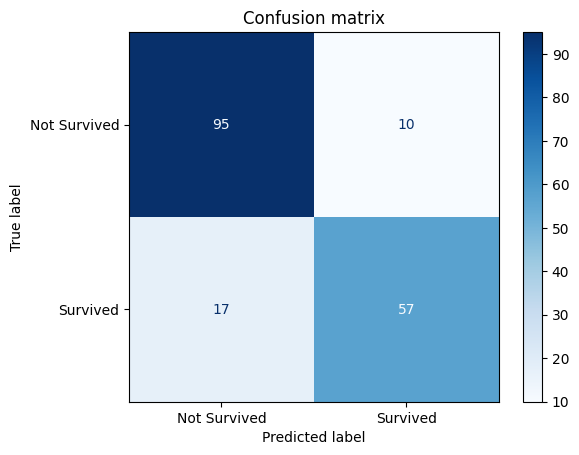

In [ ]:
confm = confusion_matrix(y_test, y_pred)
displ = ConfusionMatrixDisplay(confusion_matrix=confm, display_labels=['Not Survived', 'Survived'])
displ.plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

---

## 6: Feature importance

In [ ]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

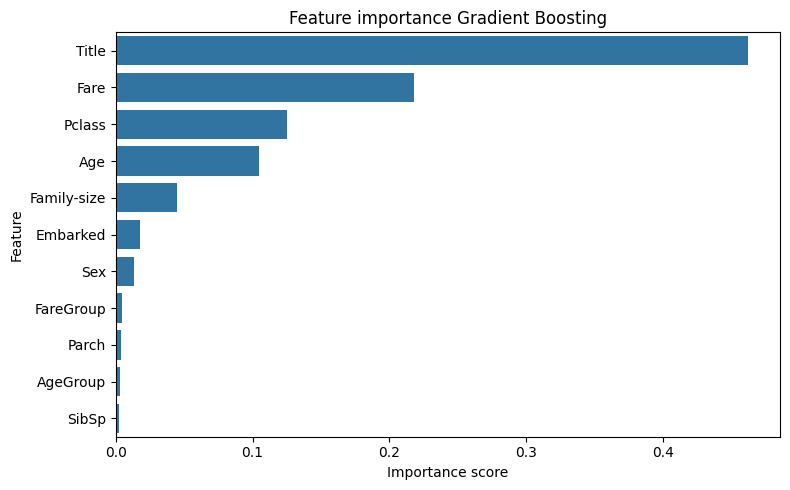

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature importance Gradient Boosting")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
print(feature_importance)

Title          0.462235
Fare           0.217934
Pclass         0.125448
Age            0.104567
Family-size    0.045146
Embarked       0.017718
Sex            0.013124
FareGroup      0.004336
Parch          0.004184
AgeGroup       0.003135
SibSp          0.002174
dtype: float64


This tells us the following: 
- Sex being the highest shows that it has influenced the most (female higher chance of survival)
- fare : the higher the fare the better the survival
- age : children were prioritised
- Pclass: higher class --> better survival
- family-size : small/mid families survived more
- Embarked / Parch / SibSp : low to no impact. 

After rerunning Title took over Sex as the most import feature. 
This makes sense, the title already captures gender and age information so the others become less usefull

In [ ]:
#Drop less significant features
X_reduced = X.drop(columns=['Sex', 'AgeGroup', 'FareGroup', 'Parch', 'SibSp'])
gb_reduced = GradientBoostingClassifier(
    learning_rate=0.2, max_depth=3, n_estimators=100, random_state=42
)

scores_reduced = cross_val_score(gb_reduced, X_reduced, y, cv=5, scoring='accuracy')

In [ ]:
print("Reduced features CV scores: ", scores_reduced)
print("Mean accuracy: ", round(scores_reduced.mean(), 4))
print("Std Dev: ", round(scores_reduced.std(), 4))

Reduced features CV scores:  [0.83240223 0.8258427  0.86516854 0.83146067 0.83146067]
Mean accuracy:  0.8373
Std Dev:  0.0141


Sources to cite:

Pandas documentation: pandas.pydata.org/docs
Scikit-learn documentation: scikit-learn.org/stable
Seaborn documentation: seaborn.pydata.org
Kaggle Titanic dataset: kaggle.com/c/titanic

AI tools used:

Claude (Anthropic) — used for step by step guidance on data cleaning, model building and evaluation

In [ ]:
# kaggle submission
test_predictions = best_model.predict(df_test_clean)

submission = pd.DataFrame(
    {
        'PassengerId': pd.read_csv('test.csv')['PassengerId'],
        'Survived': test_predictions
    }
)


submission.to_csv('submission1.csv', index=False)
print(submission.head(10))
print("Submission file saved!")

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0
Submission file saved!


In [ ]:

# Train on full training data with reduced features
X_train_red = X.drop(columns=['Sex', 'AgeGroup', 'FareGroup', 'Parch', 'SibSp'])
X_test_red = df_test_clean.drop(columns=['Sex', 'AgeGroup', 'FareGroup', 'Parch', 'SibSp'])

gb_final = GradientBoostingClassifier(
    learning_rate=0.2, max_depth=3, n_estimators=100, random_state=42
)
gb_final.fit(X_train_red, y)

test_predictions = gb_final.predict(X_test_red)

submission = pd.DataFrame({
    'PassengerId': pd.read_csv('test.csv')['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('submission2.csv', index=False)
print(submission.head(10))
print("Submission file saved!")

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0
Submission file saved!
